In [26]:
import numpy as np
import matplotlib.pyplot as plt

eeg = np.load("person-2eeg_2-per-class_run-2.npy")

print(eeg.shape)

(8, 21283)


In [27]:
import numpy as np

aux = np.load("person-2aux_2-per-class_run-2.npy")

print(aux.shape)

(3, 21283)


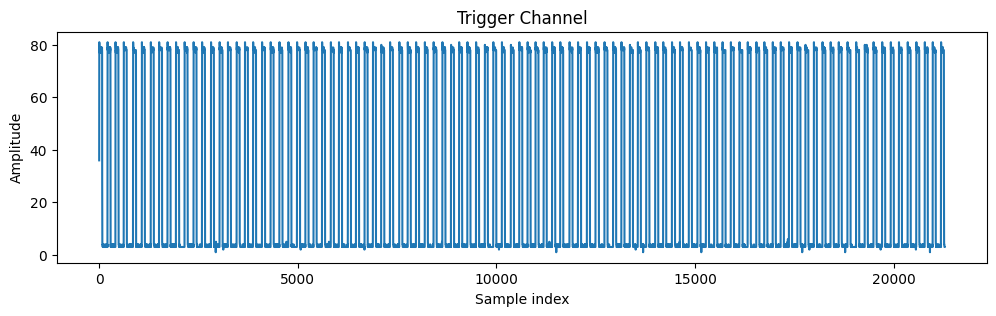

In [28]:
trigger = aux[1, :]


plt.figure(figsize=(12,3))
plt.plot(trigger)
plt.title("Trigger Channel")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

In [29]:
threshold = np.mean(trigger) + np.std(trigger)

stim_onsets = np.where(
    (trigger[1:] > threshold) & (trigger[:-1] <= threshold)
)[0]

print("Detected stimuli:", len(stim_onsets))

Detected stimuli: 100


In [30]:
# Use inter-stimulus interval (0.9 s) to estimate fs
sample_diff = stim_onsets[1] - stim_onsets[0]
fs = sample_diff / 0.9
print(f"Estimated sampling rate: {fs:.2f} Hz")


Estimated sampling rate: 232.22 Hz


In [31]:
tmin = -0.2
tmax = 0.8 

pre = int(abs(tmin) * fs)
post = int(tmax * fs)

epochs = []
for onset in stim_onsets:
    start = onset - pre
    end = onset + post
    if start > 0 and end < eeg.shape[1]:
        epochs.append(eeg[:, start:end])

epochs = np.array(epochs)
print("Epoch shape:", epochs.shape)  # (n_trials, n_channels, n_samples)

Epoch shape: (98, 8, 231)


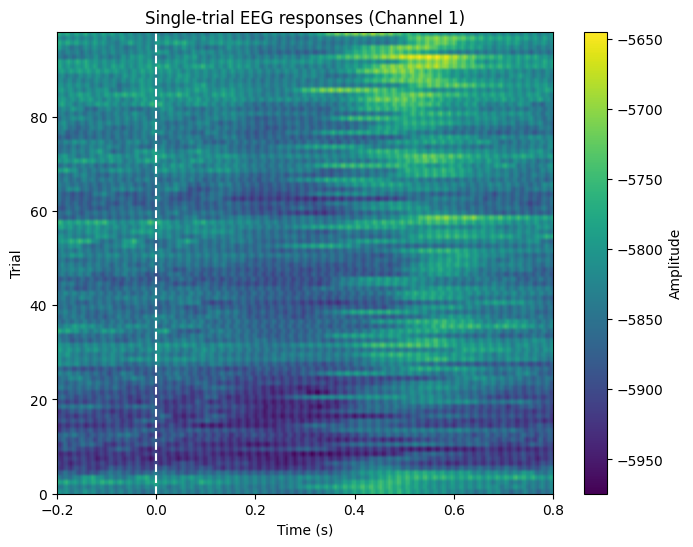

In [33]:
channel = 0  # (Channel 1 for eeg)
plt.figure(figsize=(8,6))
plt.imshow(epochs[:, channel, :], aspect='auto', extent=[tmin, tmax, 0, len(epochs)])
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title("Single-trial EEG responses (Channel 1)")
plt.show()

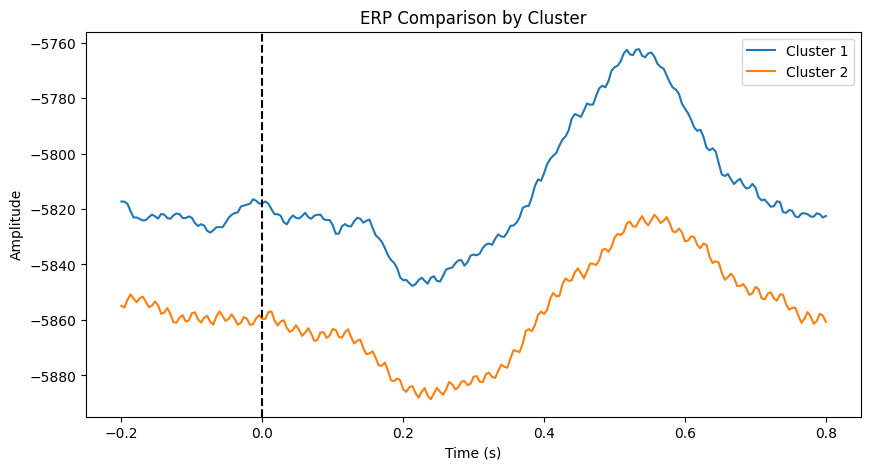

In [34]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Flatten epochs for clustering (channels x time → features)
n_trials, n_channels, n_samples = epochs.shape
X = epochs.reshape(n_trials, n_channels * n_samples)

# reduce dimensionality using PCA
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)

# Cluster into 2 groups (might correspond to recognized vs random)
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

# average ERP
cluster1 = epochs[labels==0].mean(axis=0)
cluster2 = epochs[labels==1].mean(axis=0)

time = np.linspace(tmin, tmax, n_samples)
plt.figure(figsize=(10,5))
plt.plot(time, cluster1[channel], label='Cluster 1')
plt.plot(time, cluster2[channel], label='Cluster 2')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("ERP Comparison by Cluster")
plt.legend()
plt.show()

In [35]:
window_start = int((0.1 - tmin) * fs)
window_end   = int((0.3 - tmin) * fs)

response_strength = epochs[:, channel, window_start:window_end].mean(axis=1)
strongest_trials = np.argsort(response_strength)[-10:]

print("Top 10 strongest-response trials:", strongest_trials)

Top 10 strongest-response trials: [ 0 95 26  8  2 13  7 12 14  6]


Top-response trial indices: [ 0 95 26  8  2 13  7 12 14  6]


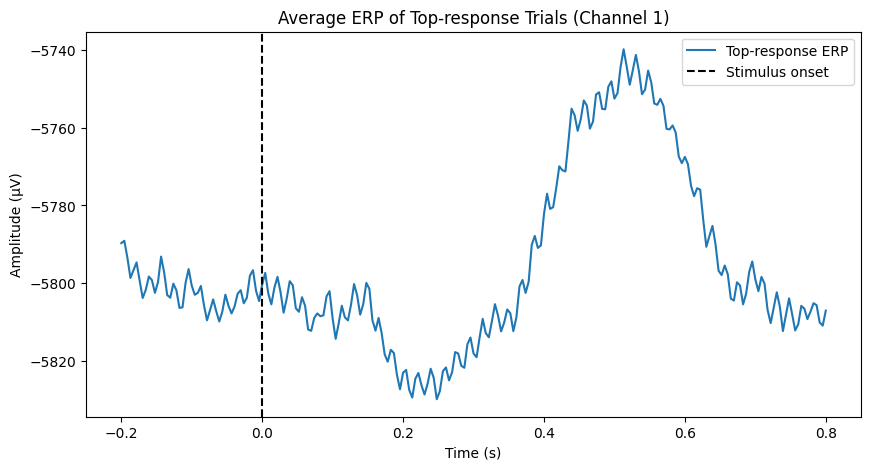

In [37]:
top_trials_idx = np.argsort(response_strength)[-10:]  # top 10 trials
print("Top-response trial indices:", top_trials_idx)

top_epochs = epochs[top_trials_idx, :, :]
erp_top = top_epochs.mean(axis=0)  # channels x samples
n_samples = erp_top.shape[1]
time = np.linspace(tmin, tmax, n_samples)

plt.figure(figsize=(10,5))
plt.plot(time, erp_top[channel], label="Top-response ERP")
plt.axvline(0, color='black', linestyle='--', label="Stimulus onset")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"Average ERP of Top-response Trials (Channel {channel+1})")
plt.legend()
plt.show()

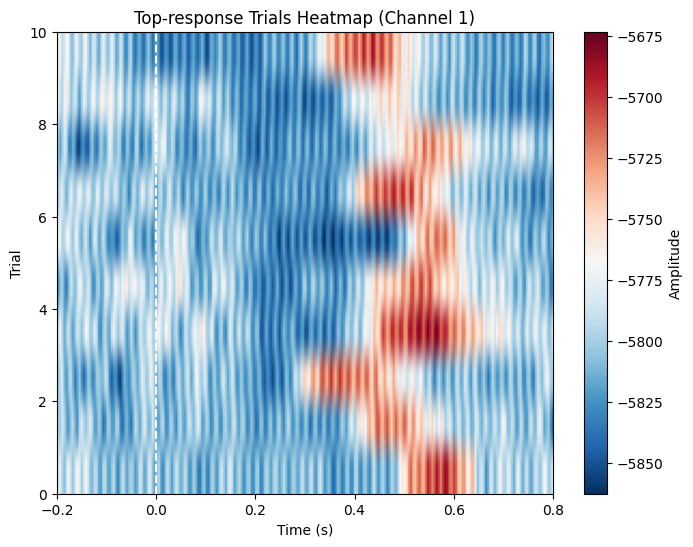

In [18]:
# Top Response Heat Map
plt.figure(figsize=(8,6))
plt.imshow(top_epochs[:, channel, :], aspect='auto', 
           extent=[tmin, tmax, 0, len(top_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Top-response Trials Heatmap (Channel {channel+1})")
plt.show()

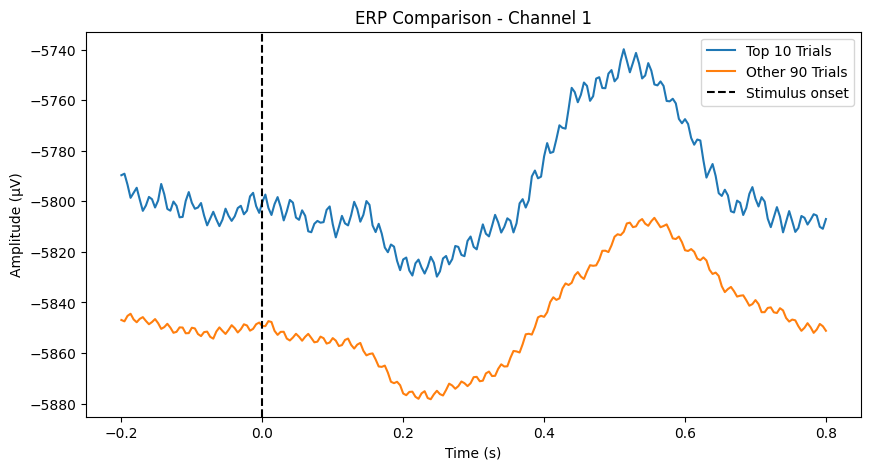

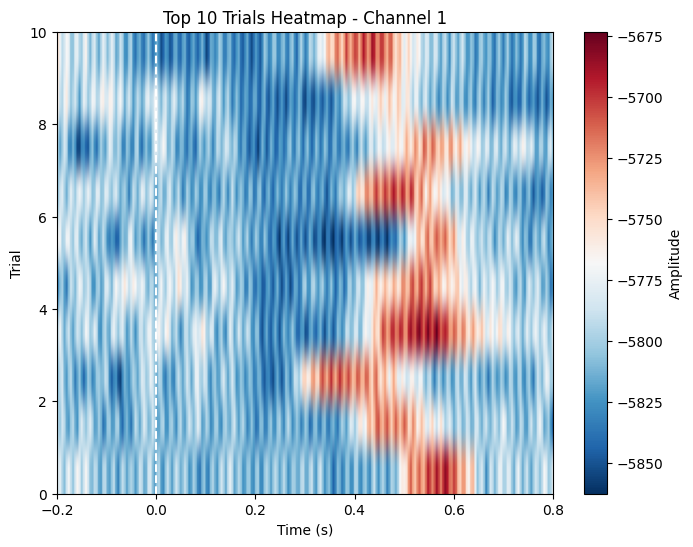

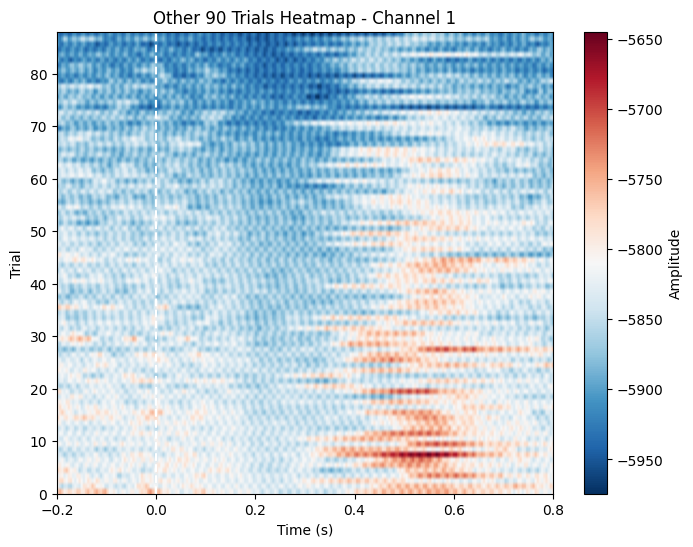

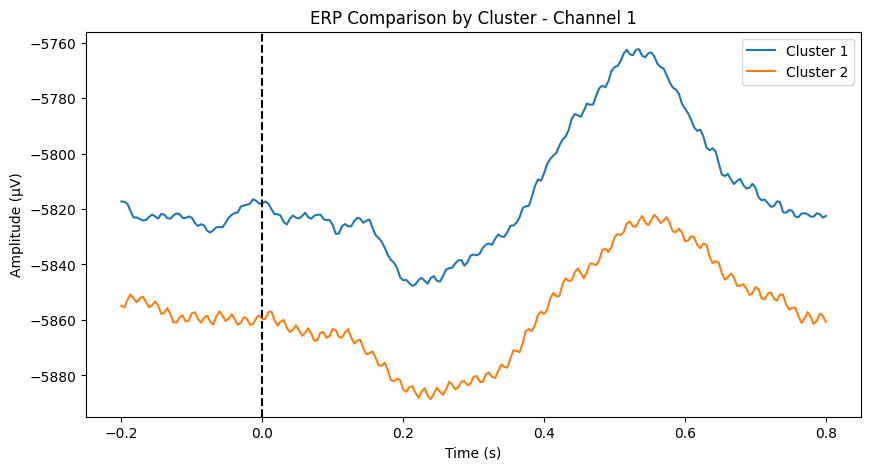

In [38]:
# Putting All Together (simpler)


top_idx = np.argsort(response_strength)[-10:]
other_idx = np.argsort(response_strength)[:-10]

top_epochs = epochs[top_idx]
other_epochs = epochs[other_idx]

erp_top = top_epochs.mean(axis=0)
erp_other = other_epochs.mean(axis=0)
n_samples = erp_top.shape[1]
time = np.linspace(tmin, tmax, n_samples)

plt.figure(figsize=(10,5))
plt.plot(time, erp_top[channel], label='Top 10 Trials')
plt.plot(time, erp_other[channel], label='Other 90 Trials')
plt.axvline(0, color='black', linestyle='--', label='Stimulus onset')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ERP Comparison - Channel {channel+1}")
plt.legend()
plt.show()


plt.figure(figsize=(8,6))
plt.imshow(top_epochs[:, channel, :], aspect='auto',
           extent=[tmin, tmax, 0, len(top_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Top 10 Trials Heatmap - Channel {channel+1}")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(other_epochs[:, channel, :], aspect='auto',
           extent=[tmin, tmax, 0, len(other_epochs)], cmap='RdBu_r')
plt.colorbar(label="Amplitude")
plt.axvline(0, color='white', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Trial")
plt.title(f"Other 90 Trials Heatmap - Channel {channel+1}")
plt.show()



n_trials, n_channels, n_samples = epochs.shape
X = epochs.reshape(n_trials, n_channels * n_samples)


pca = PCA(n_components=10)
X_pca = pca.fit_transform(X)


kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X_pca)

cluster1 = epochs[labels==0].mean(axis=0)
cluster2 = epochs[labels==1].mean(axis=0)

plt.figure(figsize=(10,5))
plt.plot(time, cluster1[channel], label='Cluster 1')
plt.plot(time, cluster2[channel], label='Cluster 2')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (µV)")
plt.title(f"ERP Comparison by Cluster - Channel {channel+1}")
plt.legend()
plt.show()

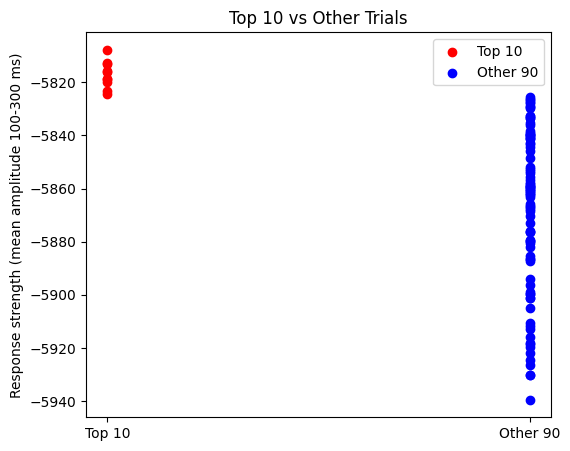

In [39]:
x_top = np.zeros(len(top_idx))
x_other = np.ones(len(other_idx))
y_top = response_strength[top_idx]
y_other = response_strength[other_idx]

plt.figure(figsize=(6,5))
plt.scatter(x_top, y_top, color='red', label='Top 10')
plt.scatter(x_other, y_other, color='blue', label='Other 90')
plt.xticks([0,1], ['Top 10', 'Other 90'])
plt.ylabel("Response strength (mean amplitude 100-300 ms)")
plt.title("Top 10 vs Other Trials")
plt.legend()
plt.show()

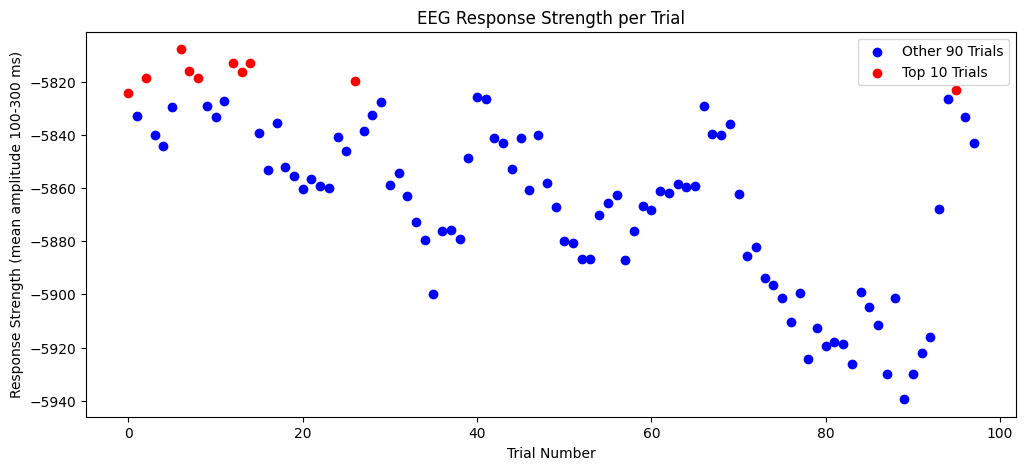

In [40]:
import matplotlib.pyplot as plt
import numpy as np

n_trials = len(response_strength)

plt.figure(figsize=(12,5))

# Other 90 trials
plt.scatter(other_idx, response_strength[other_idx], color='blue', label='Other 90 Trials')

# Top 10 trials
plt.scatter(top_idx, response_strength[top_idx], color='red', label='Top 10 Trials')

plt.xlabel("Trial Number")
plt.ylabel("Response Strength (mean amplitude 100-300 ms)")
plt.title("EEG Response Strength per Trial")
plt.legend()
plt.show()